In [ ]:
# Author : shadril238

!pip install timm scikit-learn

from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [ ]:
import os

drive_base = "/content/drive/MyDrive/ml-project1/pneumonia_experiments"

# Keep everything in Drive (checkpoint + generated images)
gan_generator_path = os.path.join(drive_base, "gan/models/generator_pneumonia.pth")
synthetic_dir      = os.path.join(drive_base, "gan/synthetic_data/PNEUMONIA")

os.makedirs(os.path.dirname(gan_generator_path), exist_ok=True)
os.makedirs(synthetic_dir, exist_ok=True)

print("GAN checkpoint will be saved at:", gan_generator_path)
print("Synthetic images will be saved at:", synthetic_dir)


GAN checkpoint will be saved at: /content/drive/MyDrive/ml-project1/pneumonia_experiments/gan/models/generator_pneumonia.pth
Synthetic images will be saved at: /content/drive/MyDrive/ml-project1/pneumonia_experiments/gan/synthetic_data/PNEUMONIA


In [ ]:
# Imports, configuration, paths

import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms

from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

BASE_DATASET_DIR = "/content/drive/MyDrive/ml-project1/dataset/Dataset"
train_dir = os.path.join(BASE_DATASET_DIR, "train")
val_dir   = os.path.join(BASE_DATASET_DIR, "val")
test_dir  = os.path.join(BASE_DATASET_DIR, "test")

# GAN related folders
os.makedirs("gan/models", exist_ok=True)
os.makedirs("gan/synthetic_data/PNEUMONIA", exist_ok=True)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Image constants
IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


Using device: cuda


Classes: ['NORMAL', 'PNEUMONIA']
Class to index: {'NORMAL': 0, 'PNEUMONIA': 1}
Train counts: {'NORMAL': 1341, 'PNEUMONIA': 3875}
Val counts: {'NORMAL': 8, 'PNEUMONIA': 8}
Test counts: {'NORMAL': 234, 'PNEUMONIA': 390}


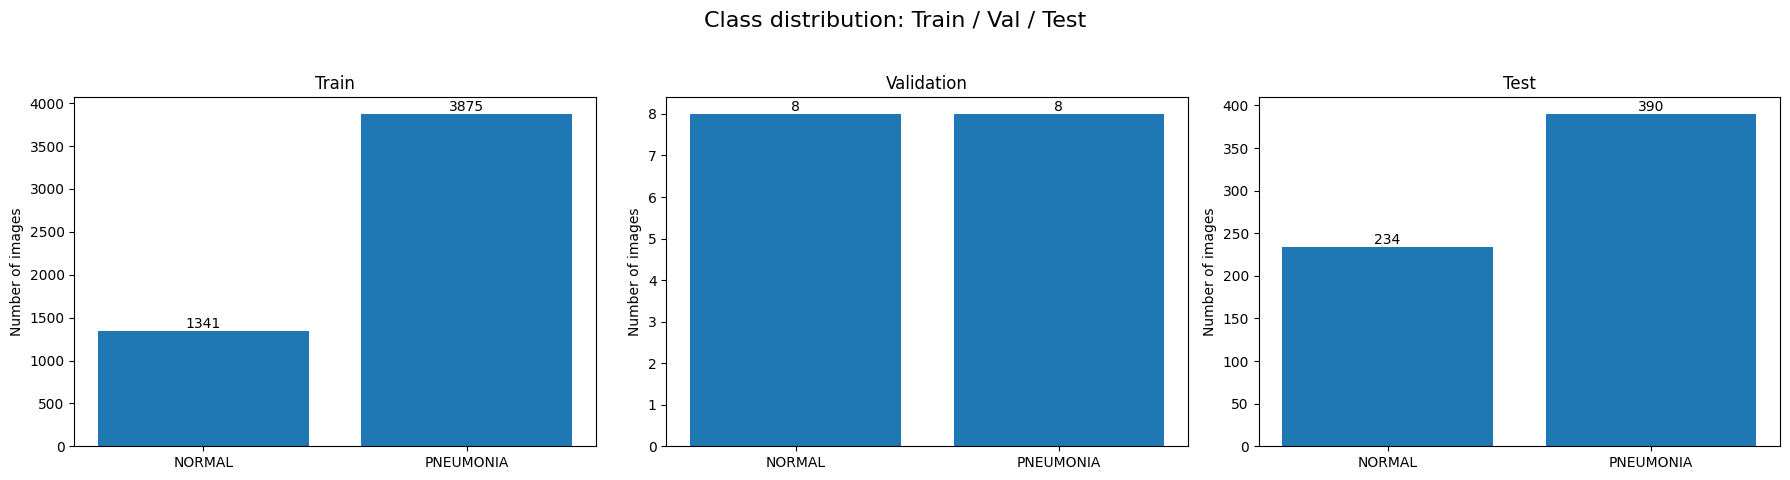

In [ ]:
# Load datasets and analyze class imbalance

from PIL import Image

basic_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
])

train_data = datasets.ImageFolder(train_dir, transform=basic_transform)
val_data   = datasets.ImageFolder(val_dir,   transform=basic_transform)
test_data  = datasets.ImageFolder(test_dir,  transform=basic_transform)

class_names = train_data.classes
print("Classes:", class_names)
print("Class to index:", train_data.class_to_idx)

def count_per_class(dataset):
    counts = [0] * len(dataset.classes)
    for label in dataset.targets:
        counts[label] += 1
    return counts

train_counts = count_per_class(train_data)
val_counts   = count_per_class(val_data)
test_counts  = count_per_class(test_data)

print("Train counts:", dict(zip(class_names, train_counts)))
print("Val counts:", dict(zip(class_names, val_counts)))
print("Test counts:", dict(zip(class_names, test_counts)))

# Visualize class distributions across splits
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Class distribution: Train / Val / Test", fontsize=16)

for ax, counts, title in zip(
    axes,
    [train_counts, val_counts, test_counts],
    ["Train", "Validation", "Test"]
):
    ax.bar(class_names, counts)
    ax.set_title(title)
    ax.set_ylabel("Number of images")
    for i, count in enumerate(counts):
        ax.text(i, count, str(count), ha="center", va="bottom")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


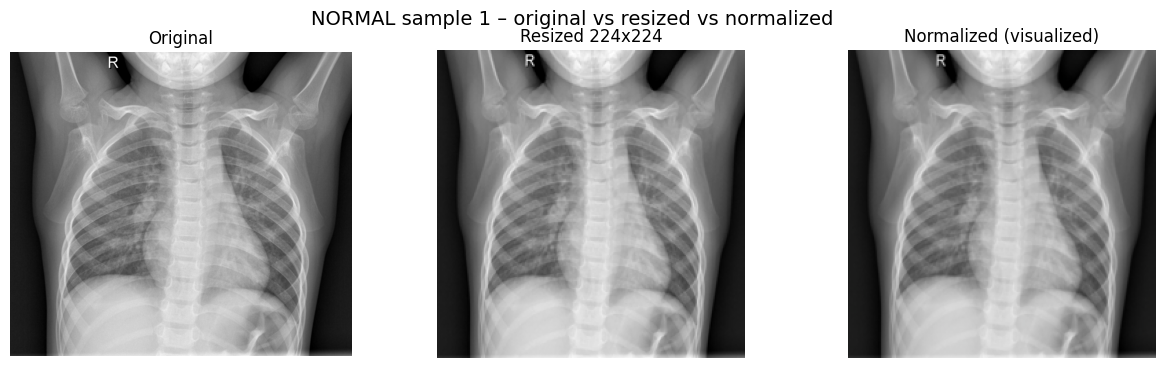

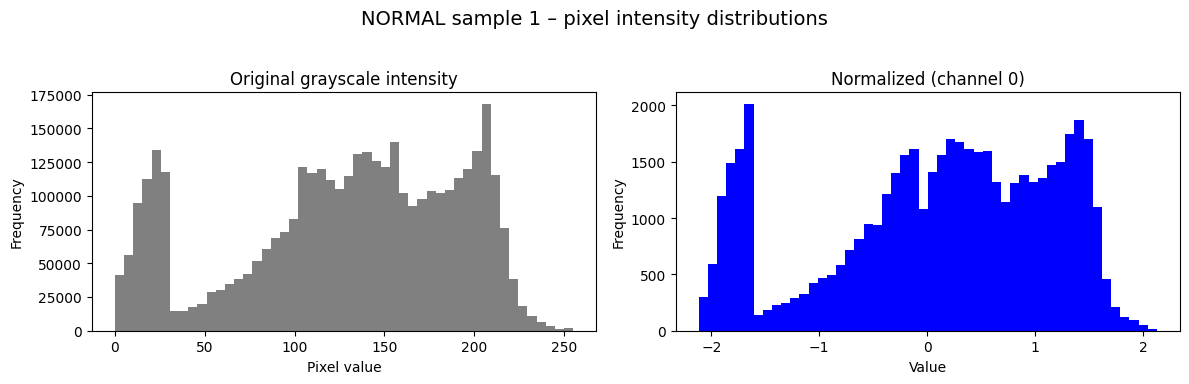

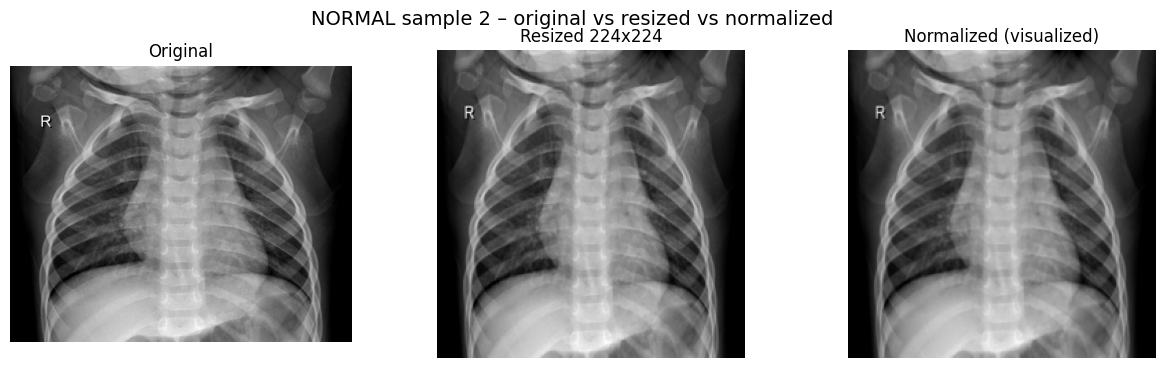

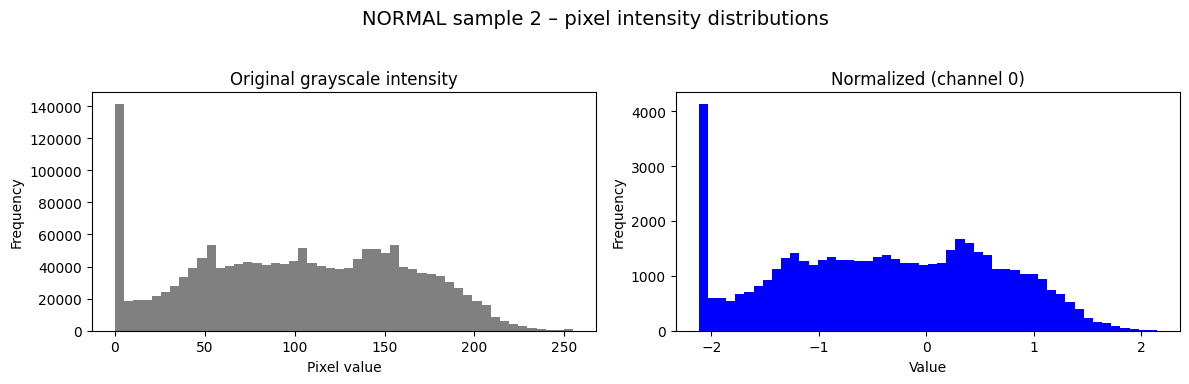

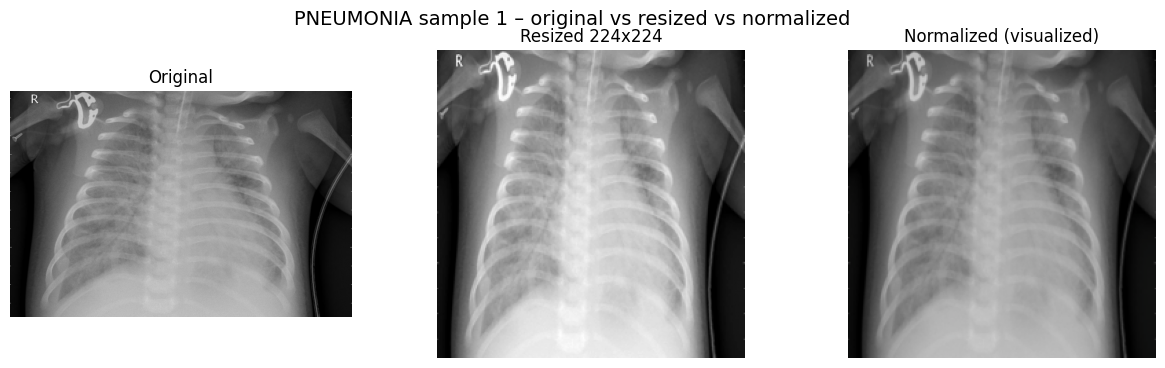

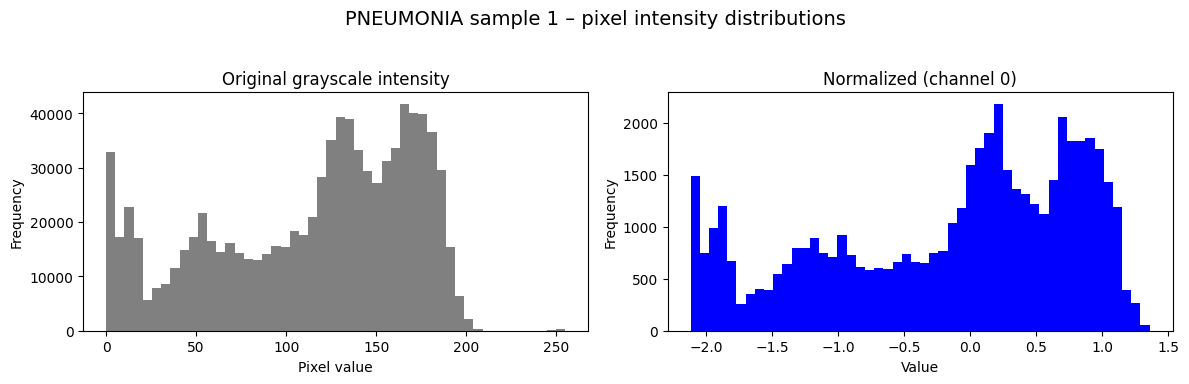

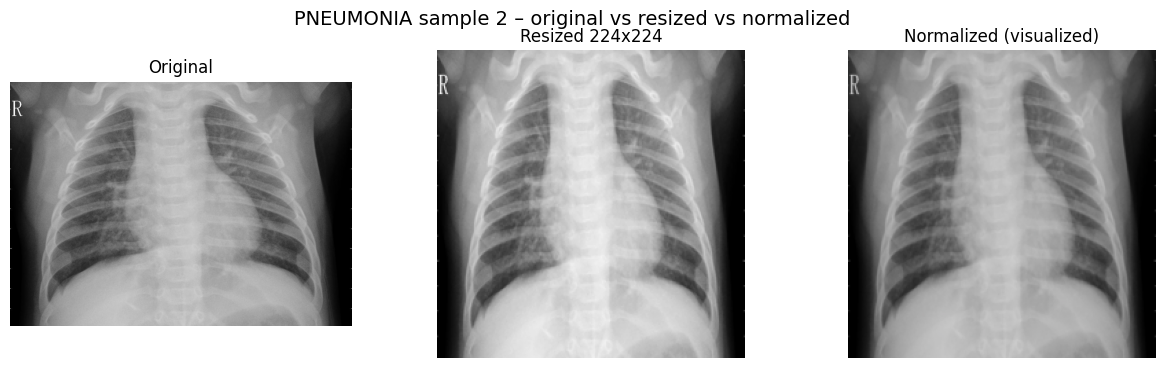

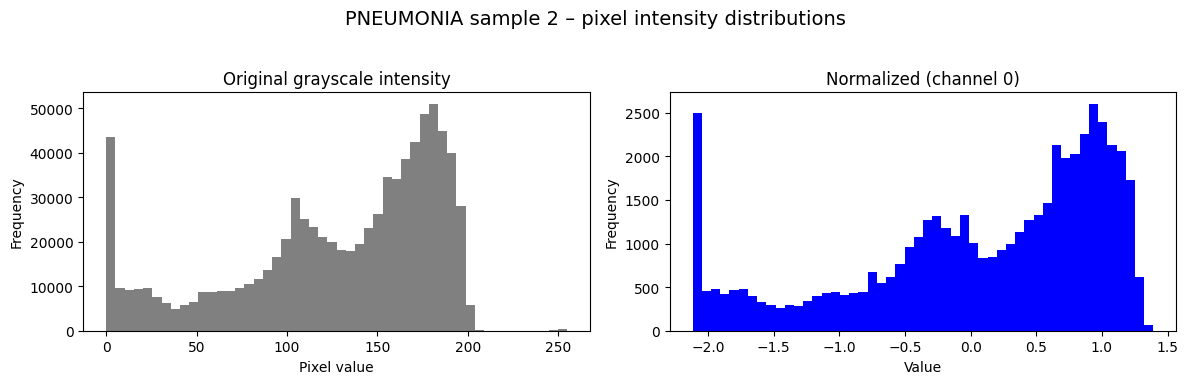

In [ ]:
# Visualizations – original, resized, normalized, pixel histograms

class_to_idx = train_data.class_to_idx
normal_idx    = class_to_idx["NORMAL"]
pneumonia_idx = class_to_idx["PNEUMONIA"]

all_samples = train_data.samples
normal_paths    = [fp for (fp, label) in all_samples if label == normal_idx]
pneumonia_paths = [fp for (fp, label) in all_samples if label == pneumonia_idx]

normalize_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

def show_image_pipeline(image_path, title_prefix=""):
    original = Image.open(image_path)
    resized  = original.resize((IMG_SIZE, IMG_SIZE))
    normalized_tensor = normalize_transform(original)
    inv_mean = [-m / s for m, s in zip(IMAGENET_MEAN, IMAGENET_STD)]
    inv_std  = [1.0 / s for s in IMAGENET_STD]
    inv_transform = transforms.Normalize(mean=inv_mean, std=inv_std)
    restored_tensor = inv_transform(normalized_tensor)
    restored_np = restored_tensor.permute(1, 2, 0).clamp(0, 1).numpy()

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f"{title_prefix} – original vs resized vs normalized", fontsize=14)

    axes[0].imshow(original, cmap="gray")
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(resized, cmap="gray")
    axes[1].set_title("Resized 224x224")
    axes[1].axis("off")

    axes[2].imshow(restored_np)
    axes[2].set_title("Normalized (visualized)")
    axes[2].axis("off")

    plt.show()

    # Histogram of pixel intensities
    original_gray = original.convert("L")
    original_arr = np.array(original_gray).flatten()

    # Normalized tensor channel 0
    norm_ch0 = normalized_tensor[0].cpu().numpy().flatten()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"{title_prefix} – pixel intensity distributions", fontsize=14)

    axes[0].hist(original_arr, bins=50, color="gray")
    axes[0].set_title("Original grayscale intensity")
    axes[0].set_xlabel("Pixel value")
    axes[0].set_ylabel("Frequency")

    axes[1].hist(norm_ch0, bins=50, color="blue")
    axes[1].set_title("Normalized (channel 0)")
    axes[1].set_xlabel("Value")
    axes[1].set_ylabel("Frequency")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

for i, path in enumerate(normal_paths[:2]):
    show_image_pipeline(path, title_prefix=f"NORMAL sample {i+1}")

for i, path in enumerate(pneumonia_paths[:2]):
    show_image_pipeline(path, title_prefix=f"PNEUMONIA sample {i+1}")


In [ ]:
# Define GAN models

%%writefile gan/models/dcgan.py
import torch
from torch import nn

class Generator(nn.Module):
    """
    Simple DCGAN-like generator for 64x64 single-channel images.
    This will be trained only on pneumonia images (minority class).
    """
    def __init__(self, latent_dim=128, img_channels=1, feature_g=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, feature_g * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(feature_g * 8),
            nn.ReLU(True),

            nn.ConvTranspose2d(feature_g * 8, feature_g * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_g * 4),
            nn.ReLU(True),

            nn.ConvTranspose2d(feature_g * 4, feature_g * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_g * 2),
            nn.ReLU(True),

            nn.ConvTranspose2d(feature_g * 2, feature_g, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_g),
            nn.ReLU(True),

            nn.ConvTranspose2d(feature_g, img_channels, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z):
        if z.dim() == 2:
            z = z.unsqueeze(-1).unsqueeze(-1)
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self, img_channels=1, feature_d=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(img_channels, feature_d, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(feature_d, feature_d * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_d * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(feature_d * 2, feature_d * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_d * 4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(feature_d * 4, feature_d * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_d * 8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(feature_d * 8, 1, 4, 1, 0, bias=False),
        )

    def forward(self, x):
        out = self.net(x)
        return out.view(-1)

def weights_init(module):
    classname = module.__class__.__name__
    if classname.find("Conv") != -1:
        nn.init.normal_(module.weight.data, 0.0, 0.02)
    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(module.weight.data, 1.0, 0.02)
        nn.init.constant_(module.bias.data, 0.0)


Writing gan/models/dcgan.py


In [ ]:
# GAN training (train_gan.py)

%%writefile gan/train_gan.py
import os
from PIL import Image
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from gan.models.dcgan import Generator, Discriminator, weights_init

class PneumoniaDataset(Dataset):
    def __init__(self, pneumonia_dir, img_size=64):
        self.img_paths = []
        for root, _, files in os.walk(pneumonia_dir):
            for fname in files:
                if fname.lower().endswith((".png", ".jpg", ".jpeg")):
                    self.img_paths.append(os.path.join(root, fname))
        if not self.img_paths:
            raise ValueError(f"No images found in {pneumonia_dir}")
        self.transform = transforms.Compose([
            transforms.Grayscale(num_output_channels=1),
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5], std=[0.5]),
        ])

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, index):
        path = self.img_paths[index]
        image = Image.open(path).convert("L")
        return self.transform(image)

def train_gan(
    pneumonia_dir,
    generator_out_path,
    img_size=64,
    latent_dim=128,
    batch_size=64,
    num_epochs=50,
    lr=2e-4,
    beta1=0.5,
    device="cuda",
):

    dataset = PneumoniaDataset(pneumonia_dir, img_size=img_size)
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=device.startswith("cuda"),
    )

    generator = Generator(latent_dim=latent_dim, img_channels=1).to(device)
    discriminator = Discriminator(img_channels=1).to(device)

    generator.apply(weights_init)
    discriminator.apply(weights_init)

    criterion = nn.BCEWithLogitsLoss()
    optimizer_g = torch.optim.Adam(generator.parameters(), lr=lr, betas=(beta1, 0.999))
    optimizer_d = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(beta1, 0.999))

    for epoch in range(num_epochs):
        generator.train()
        discriminator.train()

        total_g = 0.0
        total_d = 0.0

        for real_images in dataloader:
            real_images = real_images.to(device)
            batch_size_now = real_images.size(0)

            real_labels = torch.ones(batch_size_now, device=device)
            fake_labels = torch.zeros(batch_size_now, device=device)

            # Update Discriminator
            optimizer_d.zero_grad()
            logits_real = discriminator(real_images)
            loss_real = criterion(logits_real, real_labels)

            noise = torch.randn(batch_size_now, latent_dim, device=device)
            fake_images = generator(noise)
            logits_fake = discriminator(fake_images.detach())
            loss_fake = criterion(logits_fake, fake_labels)

            loss_d = (loss_real + loss_fake) * 0.5
            loss_d.backward()
            optimizer_d.step()

            # Update Generator
            optimizer_g.zero_grad()
            noise = torch.randn(batch_size_now, latent_dim, device=device)
            fake_images = generator(noise)
            logits_fake_for_g = discriminator(fake_images)
            loss_g = criterion(logits_fake_for_g, real_labels)
            loss_g.backward()
            optimizer_g.step()

            total_d += loss_d.item() * batch_size_now
            total_g += loss_g.item() * batch_size_now

        epoch_d = total_d / len(dataset)
        epoch_g = total_g / len(dataset)
        print(f"Epoch {epoch + 1:03d}/{num_epochs:03d}  D loss: {epoch_d:.4f}  G loss: {epoch_g:.4f}")

    torch.save(generator.state_dict(), generator_out_path)
    print(f"Training finished. Generator saved to {generator_out_path}")


Writing gan/train_gan.py


In [ ]:
# GAN synthetic pneumonia image generator (generate_images.py)

%%writefile gan/generate_images.py
import os
import torch
import numpy as np
from PIL import Image

from gan.models.dcgan import Generator

def _tensor_to_pil(img_tensor, upscale_to=224):
    img = img_tensor.detach().cpu()
    img = (img * 0.5) + 0.5
    img = img.clamp(0, 1)
    img = img.squeeze(0)

    if img.ndim == 2:
        arr = (img.numpy() * 255).astype("uint8")
        pil_img = Image.fromarray(arr, mode="L")
    else:
        arr = (img.permute(1, 2, 0).numpy() * 255).astype("uint8")
        pil_img = Image.fromarray(arr)

    if upscale_to is not None and upscale_to != img.shape[-1]:
        pil_img = pil_img.resize((upscale_to, upscale_to), Image.BILINEAR)

    return pil_img.convert("RGB")

def generate_synthetic_images(
    checkpoint_path,
    output_dir,
    num_images,
    latent_dim=128,
    img_size=64,
    device="cuda",
):
    os.makedirs(output_dir, exist_ok=True)

    generator = Generator(latent_dim=latent_dim, img_channels=1).to(device)
    generator.load_state_dict(torch.load(checkpoint_path, map_location=device))
    generator.eval()

    batch_size = 64
    num_batches = (num_images + batch_size - 1) // batch_size

    saved = 0
    with torch.no_grad():
        for _ in range(num_batches):
            remaining = num_images - saved
            current = min(batch_size, remaining)
            noise = torch.randn(current, latent_dim, device=device)
            fake_batch = generator(noise)

            for i in range(current):
                img = fake_batch[i]
                pil_img = _tensor_to_pil(img, upscale_to=224)
                filename = f"synth_{saved + 1:05d}.png"
                pil_img.save(os.path.join(output_dir, filename))
                saved += 1
                if saved >= num_images:
                    break

    print(f"Saved {saved} synthetic pneumonia images in {output_dir}")


Writing gan/generate_images.py


In [ ]:
# Train GAN on minority pneumonia class

from gan.train_gan import train_gan

pneumonia_train_dir = os.path.join(train_dir, "PNEUMONIA")
# gan_generator_path = "gan/models/generator_pneumonia.pth"

train_gan(
    pneumonia_dir=pneumonia_train_dir,
    generator_out_path=gan_generator_path,
    img_size=64,
    latent_dim=128,
    batch_size=64,
    num_epochs=50,
    lr=2e-4,
    device=device.type,
)


Epoch 001/050  D loss: 0.3050  G loss: 12.4551
Epoch 002/050  D loss: 0.5505  G loss: 8.9383
Epoch 003/050  D loss: 0.3735  G loss: 5.2908
Epoch 004/050  D loss: 0.3424  G loss: 3.4731
Epoch 005/050  D loss: 0.3490  G loss: 3.8776
Epoch 006/050  D loss: 0.3643  G loss: 4.6123
Epoch 007/050  D loss: 0.3332  G loss: 4.5712
Epoch 008/050  D loss: 0.3419  G loss: 4.8867
Epoch 009/050  D loss: 0.2650  G loss: 4.7862
Epoch 010/050  D loss: 0.3211  G loss: 5.3817
Epoch 011/050  D loss: 0.2769  G loss: 5.1414
Epoch 012/050  D loss: 0.2472  G loss: 5.0491
Epoch 013/050  D loss: 0.2469  G loss: 5.0230
Epoch 014/050  D loss: 0.2587  G loss: 5.2025
Epoch 015/050  D loss: 0.2498  G loss: 5.2232
Epoch 016/050  D loss: 0.2588  G loss: 5.1599
Epoch 017/050  D loss: 0.2111  G loss: 5.0520
Epoch 018/050  D loss: 0.2776  G loss: 5.3166
Epoch 019/050  D loss: 0.2225  G loss: 5.1263
Epoch 020/050  D loss: 0.2830  G loss: 5.3504
Epoch 021/050  D loss: 0.2229  G loss: 5.2671
Epoch 022/050  D loss: 0.2545  G 

GAN checkpoint: /content/drive/MyDrive/ml-project1/pneumonia_experiments/gan/models/generator_pneumonia.pth
Synthetic output folder: /content/drive/MyDrive/ml-project1/pneumonia_experiments/gan/synthetic_data/PNEUMONIA
Existing synthetic images: 0
Need to generate: 5000
Saved 5000 synthetic pneumonia images in /content/drive/MyDrive/ml-project1/pneumonia_experiments/gan/synthetic_data/PNEUMONIA
Final synthetic image count: 5000


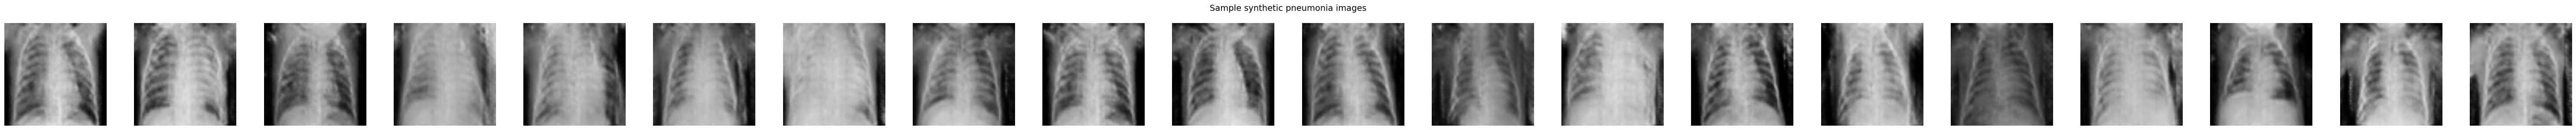

In [ ]:
# Generate synthetic pneumonia images

from gan.generate_images import generate_synthetic_images
from PIL import Image
import os
import matplotlib.pyplot as plt

NUM_GAN_IMAGES = 5000
CLEAR_EXISTING = True
VISUALIZE_N    = 20

os.makedirs(synthetic_dir, exist_ok=True)

if CLEAR_EXISTING:
    for f in os.listdir(synthetic_dir):
        if f.lower().endswith((".png", ".jpg", ".jpeg")):
            os.remove(os.path.join(synthetic_dir, f))

existing = len([
    f for f in os.listdir(synthetic_dir)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
])
to_generate = max(0, NUM_GAN_IMAGES - existing)

print("GAN checkpoint:", gan_generator_path)
print("Synthetic output folder:", synthetic_dir)
print("Existing synthetic images:", existing)
print("Need to generate:", to_generate)

if to_generate > 0:
    generate_synthetic_images(
        checkpoint_path=gan_generator_path,
        output_dir=synthetic_dir,
        num_images=to_generate,
        latent_dim=128,
        img_size=64,
        device=device.type,
    )

final_count = len([
    f for f in os.listdir(synthetic_dir)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
])
print("Final synthetic image count:", final_count)

synth_files = sorted([
    os.path.join(synthetic_dir, f)
    for f in os.listdir(synthetic_dir)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
])

num_show = min(VISUALIZE_N, len(synth_files))
if num_show > 0:
    fig, axes = plt.subplots(1, num_show, figsize=(3 * num_show, 3))
    fig.suptitle("Sample synthetic pneumonia images", fontsize=14)

    if num_show == 1:
        axes = [axes]

    for i in range(num_show):
        img = Image.open(synth_files[i])
        axes[i].imshow(img, cmap="gray")
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("No synthetic images found to display.")


GAN folder: /content/drive/MyDrive/ml-project1/pneumonia_experiments/gan/synthetic_data/PNEUMONIA
GAN image count: 5000

PNEUMONIA folder: /content/drive/MyDrive/ml-project1/dataset/Dataset/train/PNEUMONIA
PNEUMONIA image count: 3875


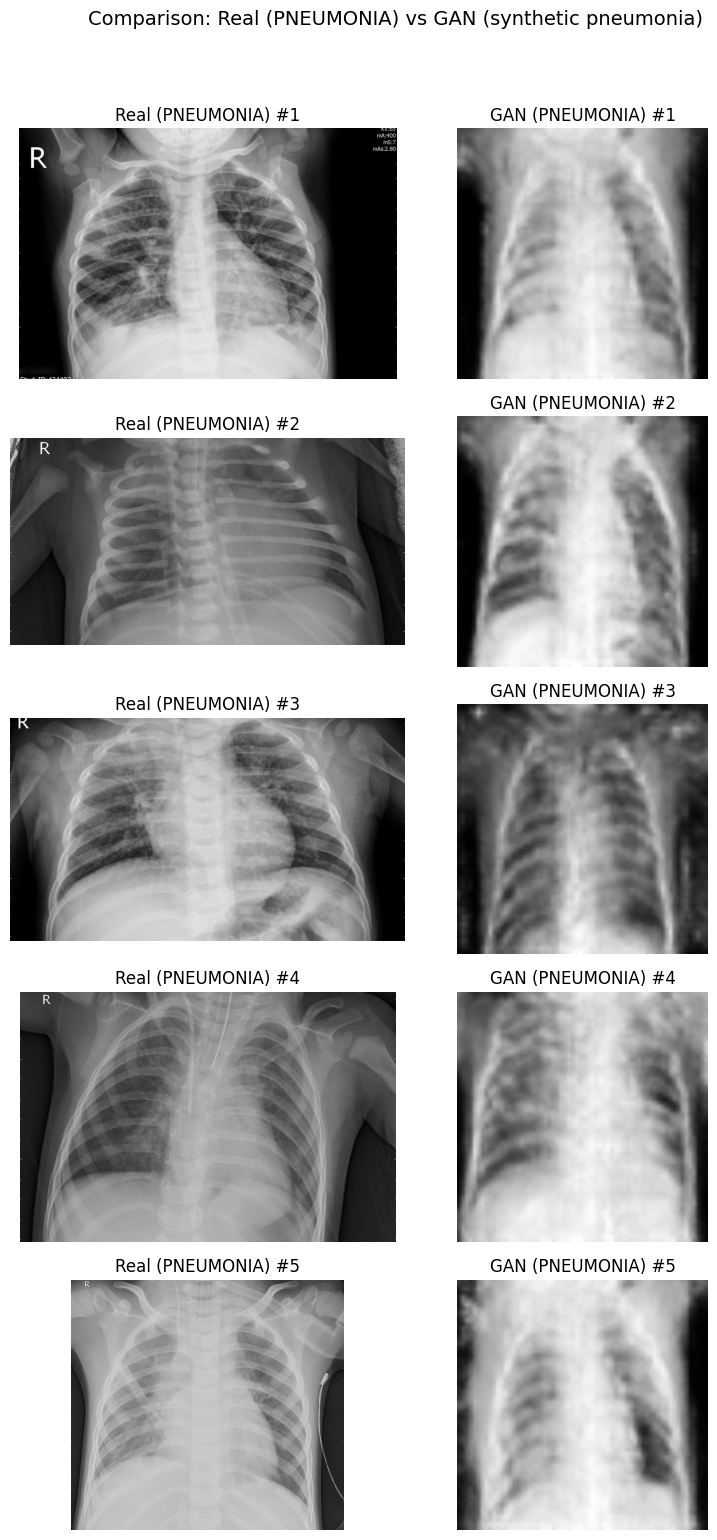

In [ ]:

import os, random
from PIL import Image
import matplotlib.pyplot as plt

# Paths
gan_dir    = "/content/drive/MyDrive/ml-project1/pneumonia_experiments/gan/synthetic_data/PNEUMONIA"
normal_dir = "/content/drive/MyDrive/ml-project1/dataset/Dataset/train/PNEUMONIA"

img_ext = (".png", ".jpg", ".jpeg")

def list_images(folder):
    if not os.path.exists(folder):
        return []
    files = []
    for root, _, fnames in os.walk(folder):
        for f in fnames:
            if f.lower().endswith(img_ext):
                files.append(os.path.join(root, f))
    return sorted(files)

gan_files = list_images(gan_dir)
normal_files = list_images(normal_dir)

print("GAN folder:", gan_dir)
print("GAN image count:", len(gan_files))
print()
print("PNEUMONIA folder:", normal_dir)
print("PNEUMONIA image count:", len(normal_files))

n_show = 5
if len(gan_files) == 0 or len(normal_files) == 0:
    print("\nCould not visualize because one of the folders has 0 images.")
else:
    random.seed(42)
    gan_pick = random.sample(gan_files, k=min(n_show, len(gan_files)))
    normal_pick = random.sample(normal_files, k=min(n_show, len(normal_files)))

    rows = min(len(gan_pick), len(normal_pick))
    fig, axes = plt.subplots(rows, 2, figsize=(8, 3.2 * rows))
    fig.suptitle("Comparison: Real (PNEUMONIA) vs GAN (synthetic pneumonia)", fontsize=14)

    if rows == 1:
        axes = [axes]

    for i in range(rows):
        # NORMAL
        img_n = Image.open(normal_pick[i]).convert("L")
        axes[i][0].imshow(img_n, cmap="gray")
        axes[i][0].set_title(f"Real (PNEUMONIA) #{i+1}")
        axes[i][0].axis("off")

        # GAN
        img_g = Image.open(gan_pick[i]).convert("L")
        axes[i][1].imshow(img_g, cmap="gray")
        axes[i][1].set_title(f"GAN (PNEUMONIA) #{i+1}")
        axes[i][1].axis("off")

    plt.tight_layout(rect=[0, 0.02, 1, 0.95])
    plt.show()


In [ ]:
# Mixed dataset (real + synthetic)

class MixedChestXrayDataset(Dataset):
    """
    Combine original train set with synthetic pneumonia images.
    """
    def __init__(self, base_dataset, synthetic_dir=None, transform=None):
        self.base_dataset = base_dataset
        self.transform = transform
        self.class_to_idx = base_dataset.class_to_idx
        self.classes = base_dataset.classes
        self.samples = list(base_dataset.samples)
        if synthetic_dir is not None:
            pneumonia_label = self.class_to_idx["PNEUMONIA"]
            for root, _, files in os.walk(synthetic_dir):
                for fname in files:
                    if fname.lower().endswith((".png", ".jpg", ".jpeg")):
                        self.samples.append(
                            (os.path.join(root, fname), pneumonia_label)
                        )
        self.targets = [label for (_, label) in self.samples]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        path, label = self.samples[index]
        img = Image.open(path).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        return img, label

def make_dataloaders(
    train_transform,
    batch_size=32,
    use_gan=False,
    synthetic_dir="gan/synthetic_data/PNEUMONIA",
):
    if use_gan:
        base_train_dataset = datasets.ImageFolder(train_dir)
        train_dataset = MixedChestXrayDataset(
            base_dataset=base_train_dataset,
            synthetic_dir=synthetic_dir,
            transform=train_transform,
        )
    else:
        train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)

    val_test_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])

    val_dataset = datasets.ImageFolder(val_dir, transform=val_test_transform)
    test_dataset = datasets.ImageFolder(test_dir, transform=val_test_transform)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=True if device.type == "cuda" else False,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True if device.type == "cuda" else False,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True if device.type == "cuda" else False,
    )

    print("Train size:", len(train_dataset))
    print("Val size:", len(val_dataset))
    print("Test size:", len(test_dataset))
    return train_loader, val_loader, test_loader


In [ ]:
# Model creation and training utilities
import timm
import time
import copy

def create_model(model_name):
    model = timm.create_model(
        model_name,
        pretrained=True,
        num_classes=1,
        in_chans=3,
    )
    return model.to(device)

def train_classifier(
    model,
    train_loader,
    num_epochs,
    lr,
    experiment_name,
):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "train_acc": []}

    for epoch in range(num_epochs):
        start = time.time()
        model.train()
        running_loss = 0.0
        running_corrects = 0
        total_samples = 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device).float().unsqueeze(1)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            preds = (torch.sigmoid(outputs) >= 0.5).long()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.long())
            total_samples += inputs.size(0)

        epoch_loss = running_loss / total_samples
        epoch_acc  = running_corrects.double().item() / total_samples

        history["train_loss"].append(epoch_loss)
        history["train_acc"].append(epoch_acc)

        elapsed = time.time() - start
        print(
            f"Epoch {epoch + 1:03d}/{num_epochs:03d} "
            f"Train loss: {epoch_loss:.4f}  "
            f"Train acc: {epoch_acc:.4f}  "
            f"Time: {elapsed:.1f}s"
        )

    # Save final weights
    os.makedirs("checkpoints", exist_ok=True)
    torch.save(model.state_dict(), f"checkpoints/{experiment_name}.pth")
    print(f"Saved model weights to checkpoints/{experiment_name}.pth")
    return model, history

def evaluate_model(model, data_loader):
    model.eval()
    all_probs = []
    all_targets = []

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            probs = torch.sigmoid(outputs).squeeze(1)

            all_probs.extend(probs.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())

    all_probs = np.array(all_probs)
    all_targets = np.array(all_targets)

    preds = (all_probs >= 0.5).astype(int)

    acc  = accuracy_score(all_targets, preds)
    rec  = recall_score(all_targets, preds)
    f1   = f1_score(all_targets, preds)
    try:
        auroc = roc_auc_score(all_targets, all_probs)
    except ValueError:
        auroc = float("nan")

    return {"accuracy": acc, "recall": rec, "f1": f1, "auroc": auroc}


Train size: 5216
Val size: 16
Test size: 624


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Epoch 001/015 Train loss: 0.3055  Train acc: 0.9354  Time: 167.4s
Epoch 002/015 Train loss: 0.0425  Train acc: 0.9860  Time: 52.2s
Epoch 003/015 Train loss: 0.0200  Train acc: 0.9929  Time: 51.6s
Epoch 004/015 Train loss: 0.0121  Train acc: 0.9954  Time: 51.4s
Epoch 005/015 Train loss: 0.0056  Train acc: 0.9983  Time: 51.5s
Epoch 006/015 Train loss: 0.0035  Train acc: 0.9985  Time: 51.4s
Epoch 007/015 Train loss: 0.0062  Train acc: 0.9977  Time: 51.2s
Epoch 008/015 Train loss: 0.0074  Train acc: 0.9977  Time: 53.0s
Epoch 009/015 Train loss: 0.0022  Train acc: 0.9994  Time: 51.2s
Epoch 010/015 Train loss: 0.0019  Train acc: 0.9996  Time: 51.3s
Epoch 011/015 Train loss: 0.0083  Train acc: 0.9967  Time: 53.1s
Epoch 012/015 Train loss: 0.0024  Train acc: 0.9990  Time: 51.3s
Epoch 013/015 Train loss: 0.0118  Train acc: 0.9958  Time: 51.6s
Epoch 014/015 Train loss: 0.0094  Train acc: 0.9969  Time: 52.0s
Epoch 015/015 Train loss: 0.0067  Train acc: 0.9979  Time: 51.3s
Saved model weights to c

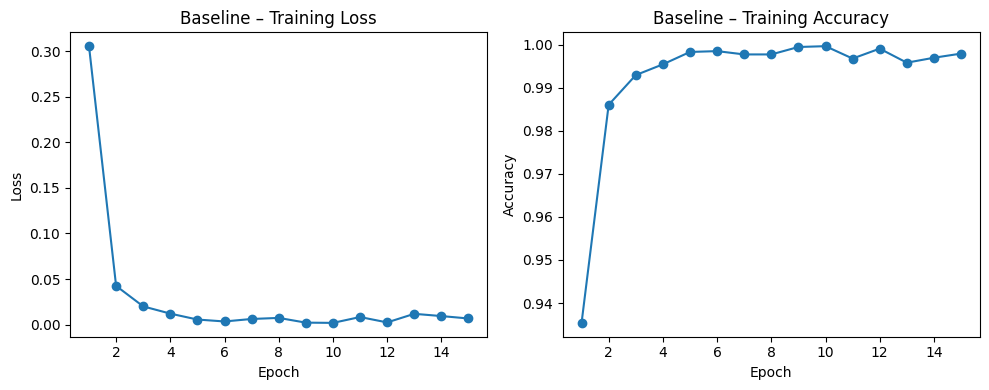

Baseline EfficientNet-B0 – Validation metrics: {'accuracy': 0.9375, 'recall': 1.0, 'f1': 0.9411764705882353, 'auroc': np.float64(1.0)}
Baseline EfficientNet-B0 – Test metrics: {'accuracy': 0.7852564102564102, 'recall': 0.9948717948717949, 'f1': 0.8527472527472527, 'auroc': np.float64(0.9386806925268464)}


In [ ]:
# Baseline EfficientNet-B0

batch_size = 32
num_epochs_baseline = 15
learning_rate = 1e-4

train_transform_baseline = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_loader_b, val_loader_b, test_loader_b = make_dataloaders(
    train_transform=train_transform_baseline,
    batch_size=batch_size,
    use_gan=False,
)

model_eff_baseline = create_model("efficientnet_b0")
model_eff_baseline, hist_baseline = train_classifier(
    model_eff_baseline,
    train_loader_b,
    num_epochs=num_epochs_baseline,
    lr=learning_rate,
    experiment_name="effnet_baseline_imbalanced",
)

epochs_range = range(1, num_epochs_baseline + 1)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, hist_baseline["train_loss"], marker="o")
plt.title("Baseline – Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot(epochs_range, hist_baseline["train_acc"], marker="o")
plt.title("Baseline – Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()

val_metrics_baseline  = evaluate_model(model_eff_baseline, val_loader_b)
test_metrics_baseline = evaluate_model(model_eff_baseline, test_loader_b)

print("Baseline EfficientNet-B0 – Validation metrics:", val_metrics_baseline)
print("Baseline EfficientNet-B0 – Test metrics:", test_metrics_baseline)


Train size: 5216
Val size: 16
Test size: 624
Epoch 001/015 Train loss: 0.4087  Train acc: 0.9087  Time: 62.9s
Epoch 002/015 Train loss: 0.1427  Train acc: 0.9597  Time: 57.3s
Epoch 003/015 Train loss: 0.1009  Train acc: 0.9672  Time: 59.3s
Epoch 004/015 Train loss: 0.0910  Train acc: 0.9709  Time: 57.3s
Epoch 005/015 Train loss: 0.0527  Train acc: 0.9810  Time: 57.6s
Epoch 006/015 Train loss: 0.0462  Train acc: 0.9835  Time: 56.4s
Epoch 007/015 Train loss: 0.0478  Train acc: 0.9833  Time: 56.3s
Epoch 008/015 Train loss: 0.0400  Train acc: 0.9862  Time: 56.9s
Epoch 009/015 Train loss: 0.0398  Train acc: 0.9849  Time: 56.9s
Epoch 010/015 Train loss: 0.0226  Train acc: 0.9914  Time: 57.8s
Epoch 011/015 Train loss: 0.0292  Train acc: 0.9904  Time: 57.1s
Epoch 012/015 Train loss: 0.0214  Train acc: 0.9912  Time: 58.8s
Epoch 013/015 Train loss: 0.0226  Train acc: 0.9923  Time: 58.7s
Epoch 014/015 Train loss: 0.0286  Train acc: 0.9893  Time: 56.3s
Epoch 015/015 Train loss: 0.0208  Train acc: 

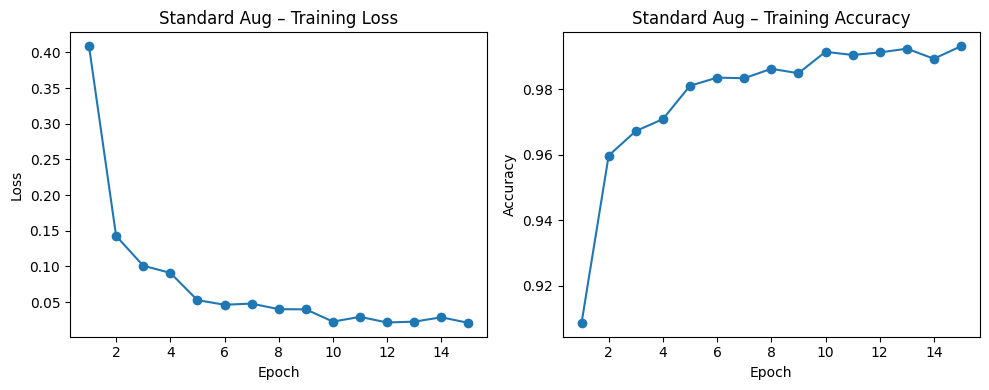

Standard Augmentation EfficientNet-B0 – Validation metrics: {'accuracy': 1.0, 'recall': 1.0, 'f1': 1.0, 'auroc': np.float64(1.0)}
Standard Augmentation EfficientNet-B0 – Test metrics: {'accuracy': 0.9262820512820513, 'recall': 0.9897435897435898, 'f1': 0.9437652811735942, 'auroc': np.float64(0.9799364453210607)}


In [ ]:
# Standard augmentation EfficientNet-B0

num_epochs_aug = 15

train_transform_aug = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_loader_a, val_loader_a, test_loader_a = make_dataloaders(
    train_transform=train_transform_aug,
    batch_size=batch_size,
    use_gan=False,
)

model_eff_aug = create_model("efficientnet_b0")
model_eff_aug, hist_aug = train_classifier(
    model_eff_aug,
    train_loader_a,
    num_epochs=num_epochs_aug,
    lr=learning_rate,
    experiment_name="effnet_standard_aug",
)

epochs_range = range(1, num_epochs_aug + 1)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, hist_aug["train_loss"], marker="o")
plt.title("Standard Aug – Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot(epochs_range, hist_aug["train_acc"], marker="o")
plt.title("Standard Aug – Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()

val_metrics_aug  = evaluate_model(model_eff_aug, val_loader_a)
test_metrics_aug = evaluate_model(model_eff_aug, test_loader_a)

print("Standard Augmentation EfficientNet-B0 – Validation metrics:", val_metrics_aug)
print("Standard Augmentation EfficientNet-B0 – Test metrics:", test_metrics_aug)


Train size: 5216
Val size: 16
Test size: 624


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Epoch 001/020 Train loss: 0.1559  Train acc: 0.9415  Time: 78.3s
Epoch 002/020 Train loss: 0.1030  Train acc: 0.9615  Time: 56.6s
Epoch 003/020 Train loss: 0.0863  Train acc: 0.9666  Time: 56.8s
Epoch 004/020 Train loss: 0.0778  Train acc: 0.9739  Time: 56.5s
Epoch 005/020 Train loss: 0.0615  Train acc: 0.9791  Time: 57.5s
Epoch 006/020 Train loss: 0.0606  Train acc: 0.9770  Time: 57.0s
Epoch 007/020 Train loss: 0.0685  Train acc: 0.9741  Time: 56.8s
Epoch 008/020 Train loss: 0.0543  Train acc: 0.9810  Time: 56.3s
Epoch 009/020 Train loss: 0.0496  Train acc: 0.9818  Time: 56.7s
Epoch 010/020 Train loss: 0.0530  Train acc: 0.9814  Time: 55.6s
Epoch 011/020 Train loss: 0.0457  Train acc: 0.9835  Time: 56.0s
Epoch 012/020 Train loss: 0.0454  Train acc: 0.9841  Time: 57.5s
Epoch 013/020 Train loss: 0.0603  Train acc: 0.9781  Time: 56.3s
Epoch 014/020 Train loss: 0.0640  Train acc: 0.9758  Time: 56.1s
Epoch 015/020 Train loss: 0.0477  Train acc: 0.9827  Time: 57.1s
Epoch 016/020 Train loss:

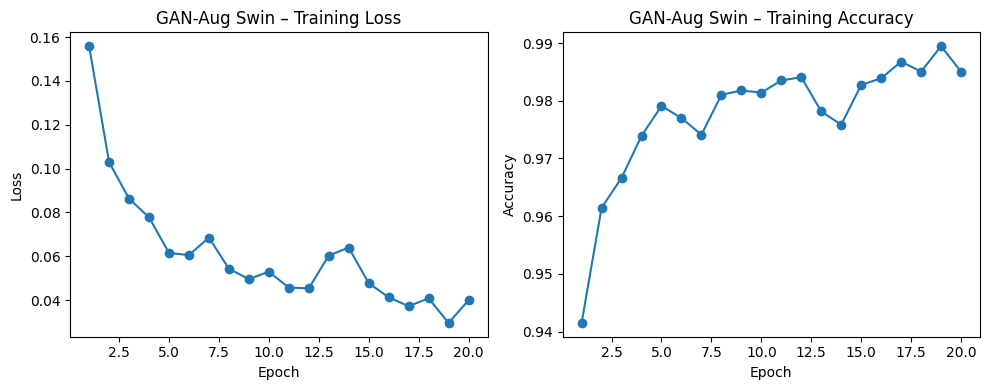

GAN-augmented Swin – Validation metrics: {'accuracy': 0.9375, 'recall': 1.0, 'f1': 0.9411764705882353, 'auroc': np.float64(1.0)}
GAN-augmented Swin – Test metrics: {'accuracy': 0.9471153846153846, 'recall': 0.9794871794871794, 'f1': 0.958594730238394, 'auroc': np.float64(0.9853659872890642)}


In [ ]:
# GAN-augmented Swin Transformer

num_epochs_swin_gan = 20

train_transform_gan = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_loader_swin_gan, val_loader_swin_gan, test_loader_swin_gan = make_dataloaders(
    train_transform=train_transform_gan,
    batch_size=batch_size,
    use_gan=True,
    synthetic_dir="gan/synthetic_data/PNEUMONIA",
)

model_swin_gan = create_model("swin_tiny_patch4_window7_224")
model_swin_gan, hist_swin_gan = train_classifier(
    model_swin_gan,
    train_loader_swin_gan,
    num_epochs=num_epochs_swin_gan,
    lr=learning_rate,
    experiment_name="swin_gan_augmented",
)

# Training curves
epochs_range = range(1, num_epochs_swin_gan + 1)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, hist_swin_gan["train_loss"], marker="o")
plt.title("GAN-Aug Swin – Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot(epochs_range, hist_swin_gan["train_acc"], marker="o")
plt.title("GAN-Aug Swin – Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()

# Validation and test metrics
val_metrics_swin_gan  = evaluate_model(model_swin_gan, val_loader_swin_gan)
test_metrics_swin_gan = evaluate_model(model_swin_gan, test_loader_swin_gan)

print("GAN-augmented Swin – Validation metrics:", val_metrics_swin_gan)
print("GAN-augmented Swin – Test metrics:", test_metrics_swin_gan)


Train size: 5216
Val size: 16
Test size: 624
Epoch 001/020 Train loss: 0.3623  Train acc: 0.9095  Time: 80.8s
Epoch 002/020 Train loss: 0.1597  Train acc: 0.9548  Time: 57.2s
Epoch 003/020 Train loss: 0.1002  Train acc: 0.9684  Time: 57.4s
Epoch 004/020 Train loss: 0.0742  Train acc: 0.9722  Time: 57.2s
Epoch 005/020 Train loss: 0.0461  Train acc: 0.9822  Time: 56.3s
Epoch 006/020 Train loss: 0.0594  Train acc: 0.9787  Time: 57.1s
Epoch 007/020 Train loss: 0.0413  Train acc: 0.9841  Time: 58.6s
Epoch 008/020 Train loss: 0.0414  Train acc: 0.9847  Time: 57.3s
Epoch 009/020 Train loss: 0.0455  Train acc: 0.9833  Time: 57.2s
Epoch 010/020 Train loss: 0.0286  Train acc: 0.9908  Time: 56.9s
Epoch 011/020 Train loss: 0.0314  Train acc: 0.9883  Time: 58.1s
Epoch 012/020 Train loss: 0.0203  Train acc: 0.9918  Time: 58.2s
Epoch 013/020 Train loss: 0.0302  Train acc: 0.9900  Time: 61.1s
Epoch 014/020 Train loss: 0.0236  Train acc: 0.9910  Time: 58.4s
Epoch 015/020 Train loss: 0.0249  Train acc: 

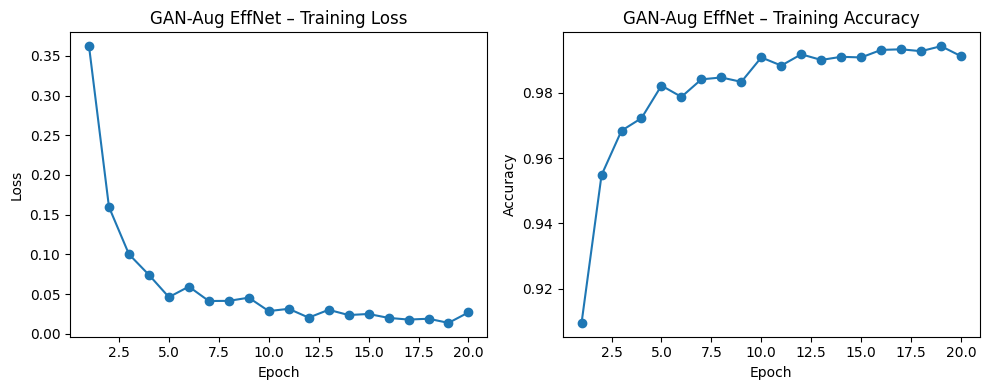

GAN-augmented EfficientNet-B0 – Validation metrics: {'accuracy': 1.0, 'recall': 1.0, 'f1': 1.0, 'auroc': np.float64(1.0)}
GAN-augmented EfficientNet-B0 – Test metrics: {'accuracy': 0.9118589743589743, 'recall': 0.9846153846153847, 'f1': 0.9331713244228432, 'auroc': np.float64(0.9799035722112646)}


In [ ]:
# GAN-augmented EfficientNet-B0

num_epochs_eff_gan = 20

train_loader_eff_gan, val_loader_eff_gan, test_loader_eff_gan = make_dataloaders(
    train_transform=train_transform_gan,
    batch_size=batch_size,
    use_gan=True,
    synthetic_dir="gan/synthetic_data/PNEUMONIA",
)

model_eff_gan = create_model("efficientnet_b0")
model_eff_gan, hist_eff_gan = train_classifier(
    model_eff_gan,
    train_loader_eff_gan,
    num_epochs=num_epochs_eff_gan,
    lr=learning_rate,
    experiment_name="effnet_gan_augmented",
)

# Training curves
epochs_range = range(1, num_epochs_eff_gan + 1)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, hist_eff_gan["train_loss"], marker="o")
plt.title("GAN-Aug EffNet – Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot(epochs_range, hist_eff_gan["train_acc"], marker="o")
plt.title("GAN-Aug EffNet – Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()

val_metrics_eff_gan  = evaluate_model(model_eff_gan, val_loader_eff_gan)
test_metrics_eff_gan = evaluate_model(model_eff_gan, test_loader_eff_gan)

print("GAN-augmented EfficientNet-B0 – Validation metrics:", val_metrics_eff_gan)
print("GAN-augmented EfficientNet-B0 – Test metrics:", test_metrics_eff_gan)



========== Train SET ==========


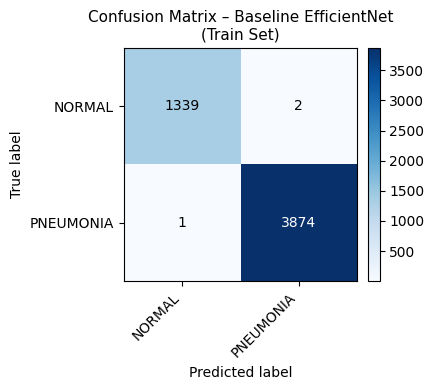

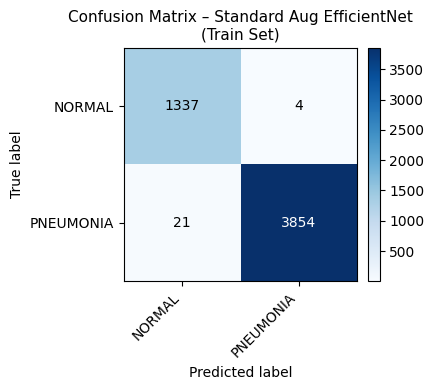

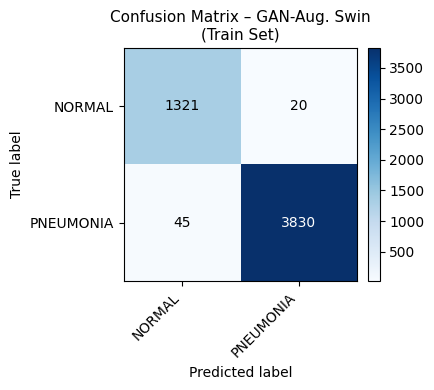

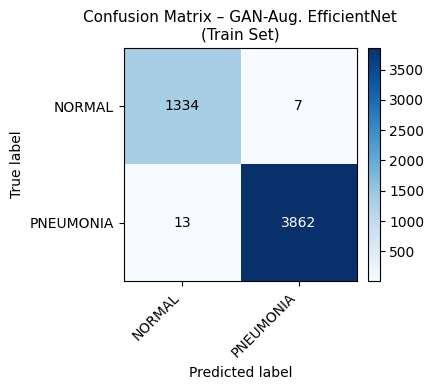

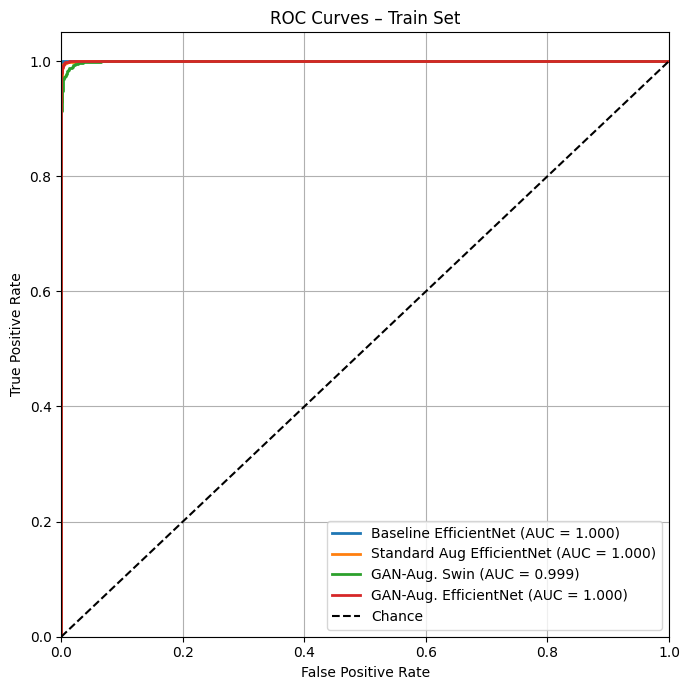

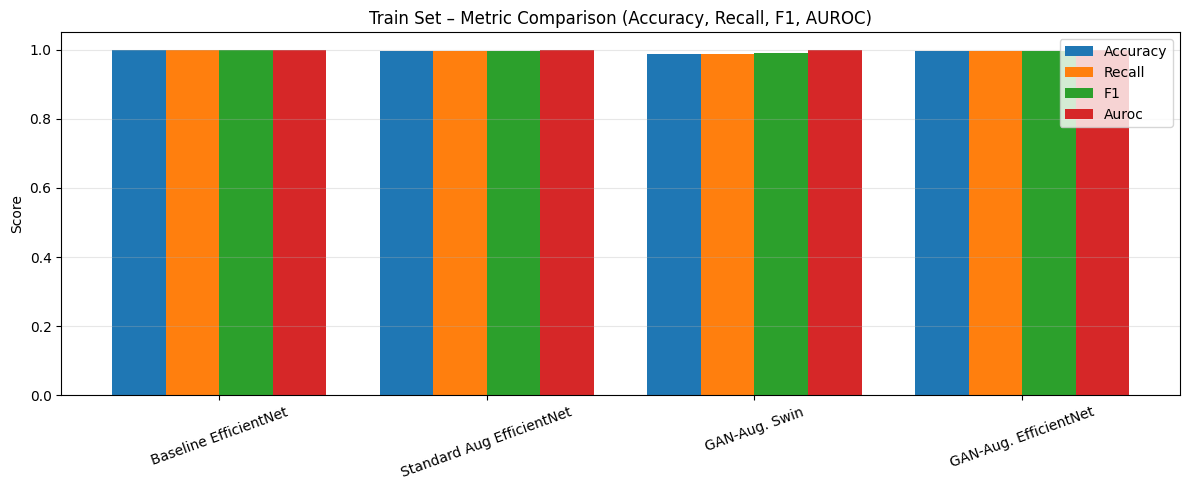


========== Validation SET ==========


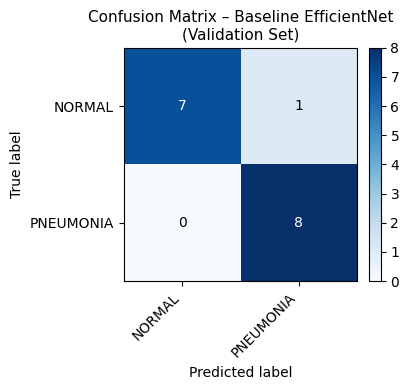

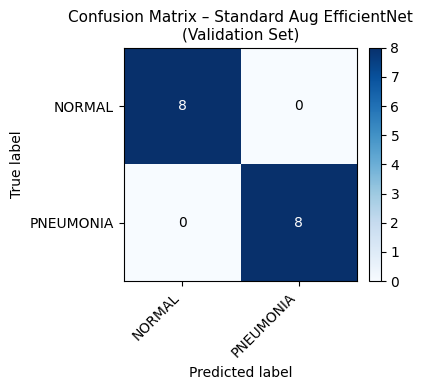

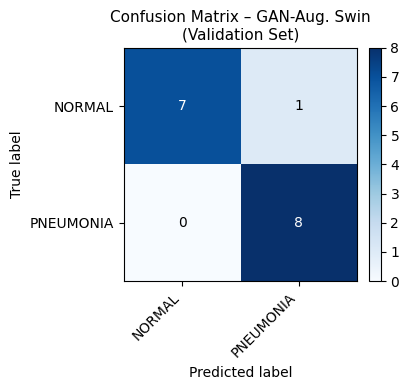

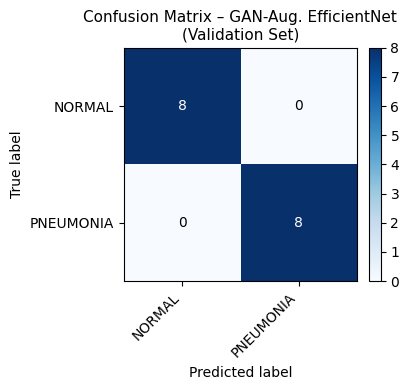

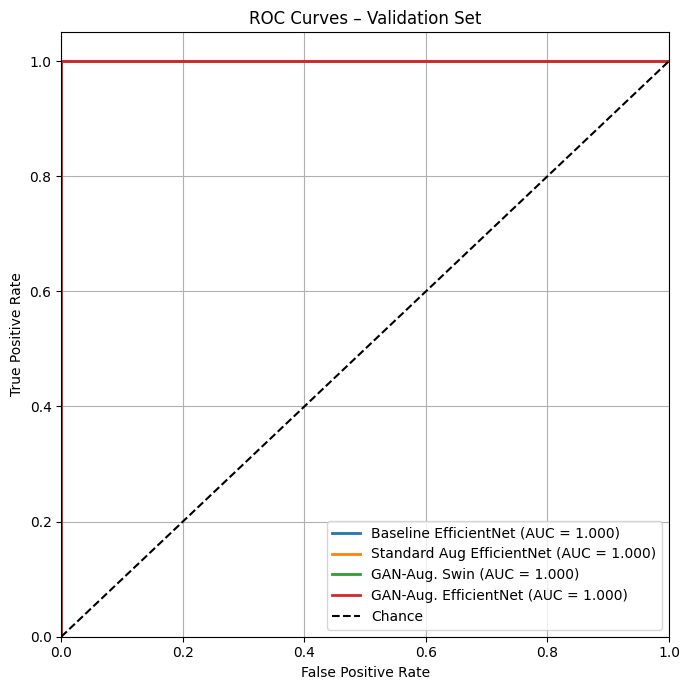

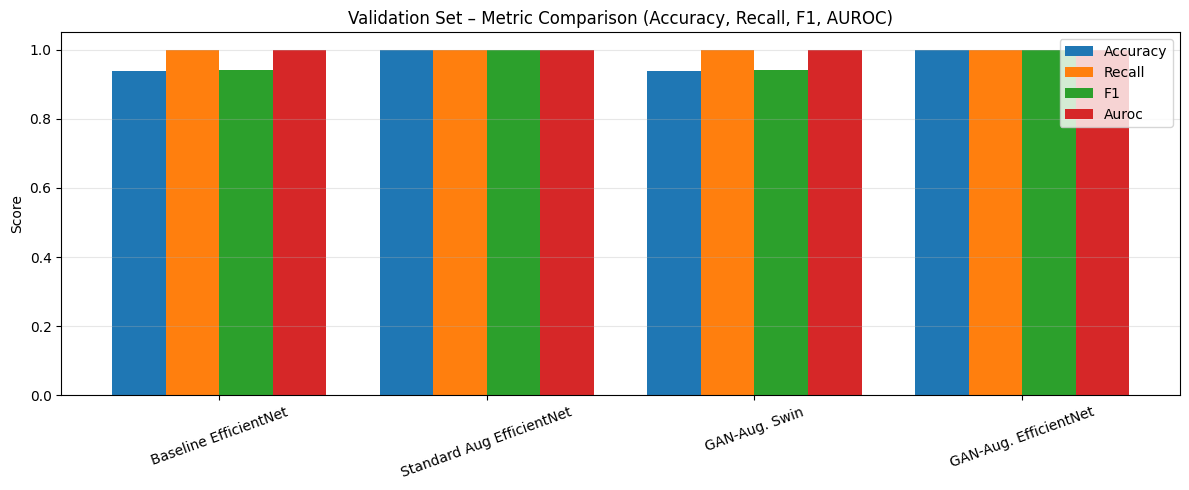


========== Test SET ==========


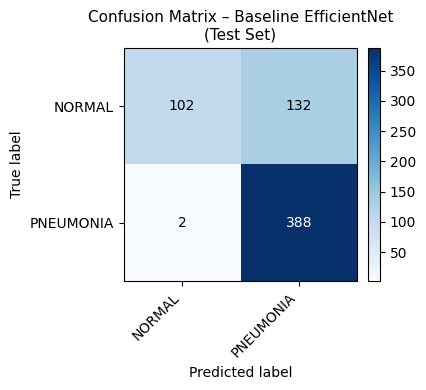

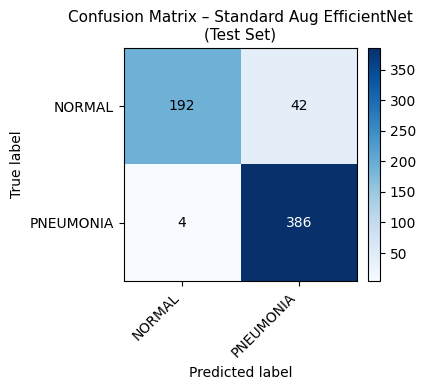

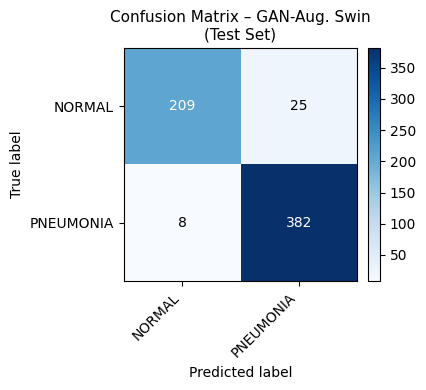

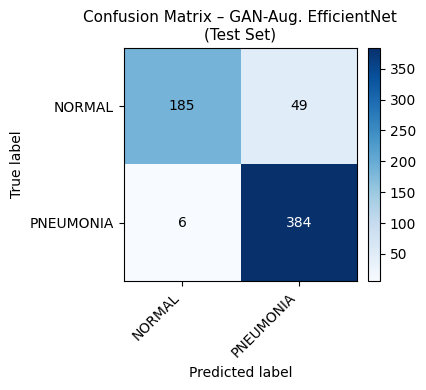

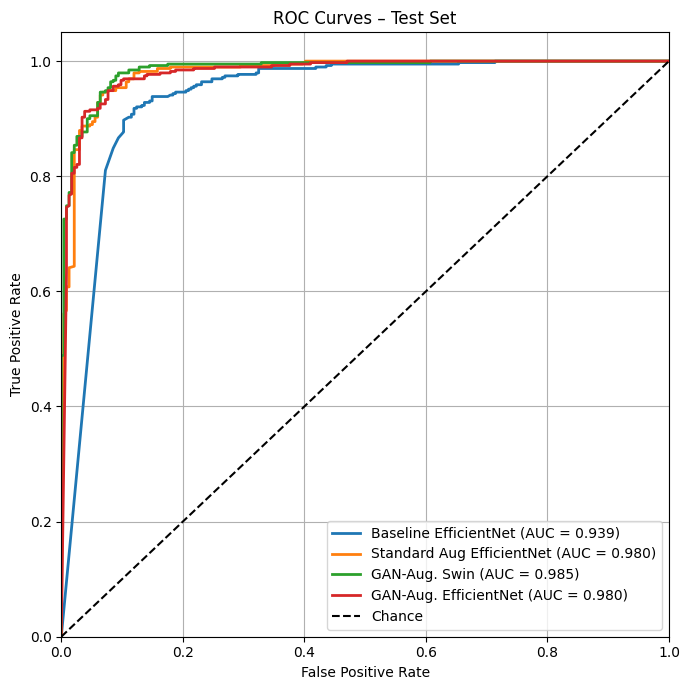

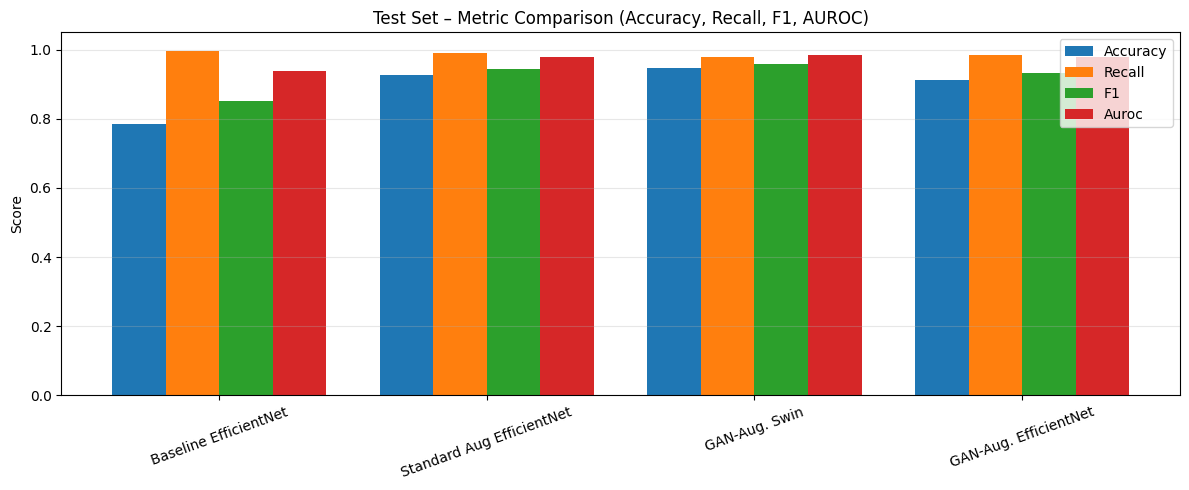

In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc,
    accuracy_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
import matplotlib.pyplot as plt

def get_predictions_and_probs(model, data_loader):
    """
    Helper: run model on a data loader and return:
    - y_true: ground truth labels (0/1)
    - y_prob: predicted probabilities for class 1 (pneumonia)
    - y_pred: predicted labels (0/1) with threshold 0.5
    """
    model.eval()
    all_probs = []
    all_targets = []

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            probs = torch.sigmoid(outputs).squeeze(1)

            all_probs.extend(probs.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())

    all_probs = np.array(all_probs)
    all_targets = np.array(all_targets)
    preds = (all_probs >= 0.5).astype(int)

    return all_targets, all_probs, preds

splits = {
    "Train": [
        ("Baseline EfficientNet",       model_eff_baseline, train_loader_b),
        ("Standard Aug EfficientNet",   model_eff_aug,      train_loader_a),
        ("GAN-Aug. Swin",               model_swin_gan,     train_loader_swin_gan),
        ("GAN-Aug. EfficientNet",       model_eff_gan,      train_loader_eff_gan),
    ],
    "Validation": [
        ("Baseline EfficientNet",       model_eff_baseline, val_loader_b),
        ("Standard Aug EfficientNet",   model_eff_aug,      val_loader_a),
        ("GAN-Aug. Swin",               model_swin_gan,     val_loader_swin_gan),
        ("GAN-Aug. EfficientNet",       model_eff_gan,      val_loader_eff_gan),
    ],
    "Test": [
        ("Baseline EfficientNet",       model_eff_baseline, test_loader_b),
        ("Standard Aug EfficientNet",   model_eff_aug,      test_loader_a),
        ("GAN-Aug. Swin",               model_swin_gan,     test_loader_swin_gan),
        ("GAN-Aug. EfficientNet",       model_eff_gan,      test_loader_eff_gan),
    ],
}

class_labels = ["NORMAL", "PNEUMONIA"]

for split_name, model_list in splits.items():
    print(f"\n========== {split_name} SET ==========")

    results = []
    for title, model, loader in model_list:
        y_true, y_prob, y_pred = get_predictions_and_probs(model, loader)
        results.append((title, y_true, y_prob, y_pred))

    for title, y_true, _, y_pred in results:
        cm = confusion_matrix(y_true, y_pred)

        plt.figure(figsize=(4.5, 4))
        im = plt.imshow(cm, interpolation="nearest", cmap="Blues")
        plt.title(f"Confusion Matrix – {title}\n({split_name} Set)", fontsize=11)
        plt.colorbar(im, fraction=0.046, pad=0.04)

        plt.xticks([0, 1], class_labels, rotation=45, ha="right")
        plt.yticks([0, 1], class_labels)
        plt.ylabel("True label")
        plt.xlabel("Predicted label")

        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                plt.text(
                    j, i, cm[i, j],
                    ha="center", va="center",
                    color="black" if cm[i, j] < cm.max() / 2 else "white",
                    fontsize=10,
                )

        plt.tight_layout()
        plt.show()

    plt.figure(figsize=(7, 7))
    for title, y_true, y_prob, _ in results:
        try:
            fpr, tpr, _ = roc_curve(y_true, y_prob)
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, linewidth=2, label=f"{title} (AUC = {roc_auc:.3f})")
        except ValueError:
            print(f"Could not compute ROC for {title} on {split_name} set (only one class?).")

    plt.plot([0, 1], [0, 1], "k--", label="Chance")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curves – {split_name} Set")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    metrics_names = ["accuracy", "recall", "f1", "auroc"]
    model_names   = [title for (title, _, _, _) in results]

    metrics_values = {m: [] for m in metrics_names}

    for title, y_true, y_prob, y_pred in results:
        acc = accuracy_score(y_true, y_pred)
        rec = recall_score(y_true, y_pred)
        f1  = f1_score(y_true, y_pred)
        try:
            auroc_val = roc_auc_score(y_true, y_prob)
        except ValueError:
            auroc_val = float("nan")

        metrics_values["accuracy"].append(acc)
        metrics_values["recall"].append(rec)
        metrics_values["f1"].append(f1)
        metrics_values["auroc"].append(auroc_val)

    x = np.arange(len(model_names))
    bar_width = 0.2

    plt.figure(figsize=(12, 5))
    for i, m in enumerate(metrics_names):
        plt.bar(x + i * bar_width, metrics_values[m], width=bar_width, label=m.capitalize())

    plt.xticks(x + bar_width * 1.5, model_names, rotation=20)
    plt.ylabel("Score")
    plt.ylim(0.0, 1.05)
    plt.title(f"{split_name} Set – Metric Comparison (Accuracy, Recall, F1, AUROC)")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


In [ ]:
drive_base = "/content/drive/MyDrive/ml-project1/pneumonia_experiments"
os.makedirs(os.path.join(drive_base, "gan/models"), exist_ok=True)
os.makedirs(os.path.join(drive_base, "gan/synthetic_data/PNEUMONIA"), exist_ok=True)
os.makedirs(os.path.join(drive_base, "checkpoints"), exist_ok=True)

gan_generator_path = os.path.join(drive_base, "gan/models/generator_pneumonia.pth")
synthetic_dir      = os.path.join(drive_base, "gan/synthetic_data/PNEUMONIA")
